In [12]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style for better visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# =========================
# 2. LOAD DATASET
# =========================
from sklearn.datasets import load_iris

iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add target column
df["species"] = iris.target

# Map numeric labels to species names
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# =========================
# 3. BASIC DATA INSPECTION
# =========================

print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

# Info summary
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Shape of dataset: (150, 5)

Column names:
 Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

First 5 rows:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 

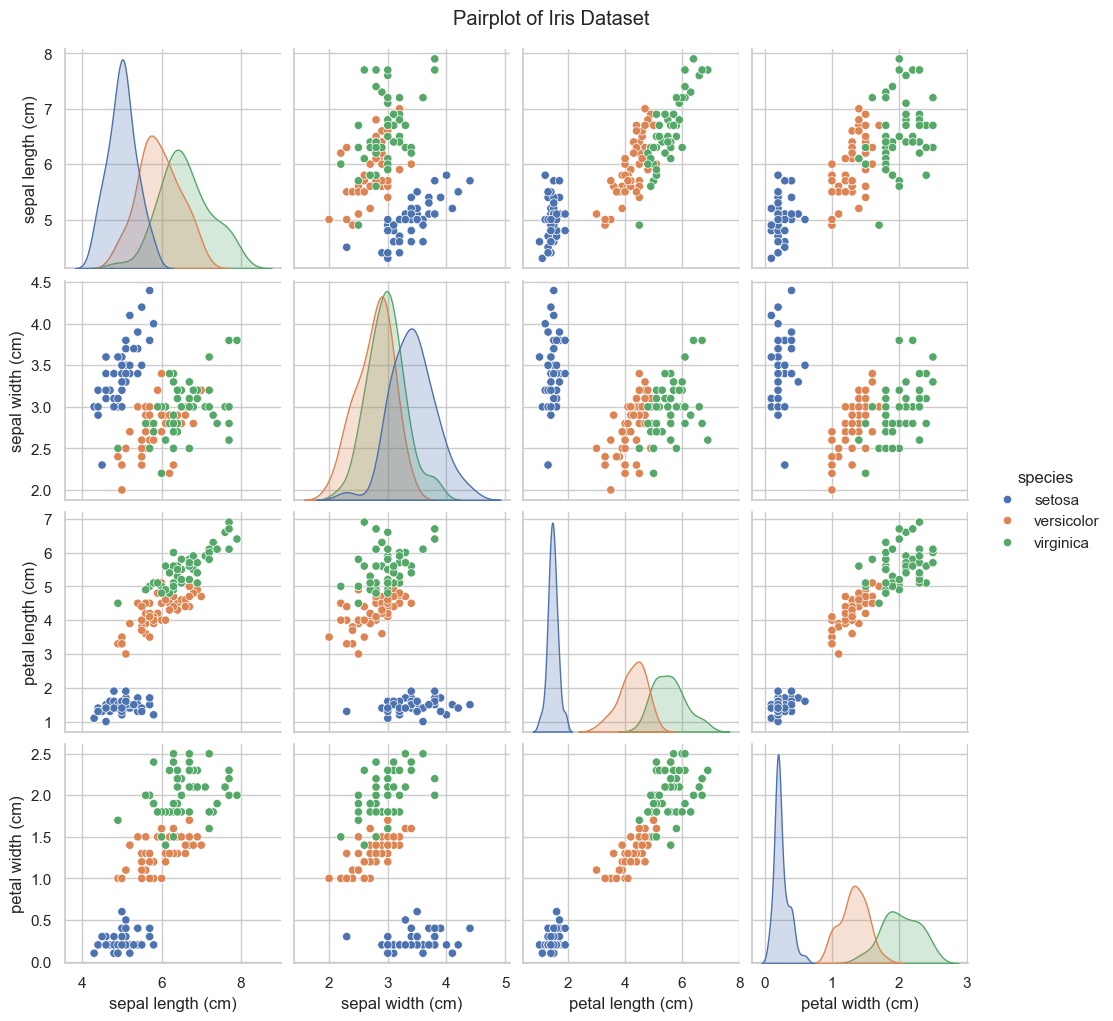

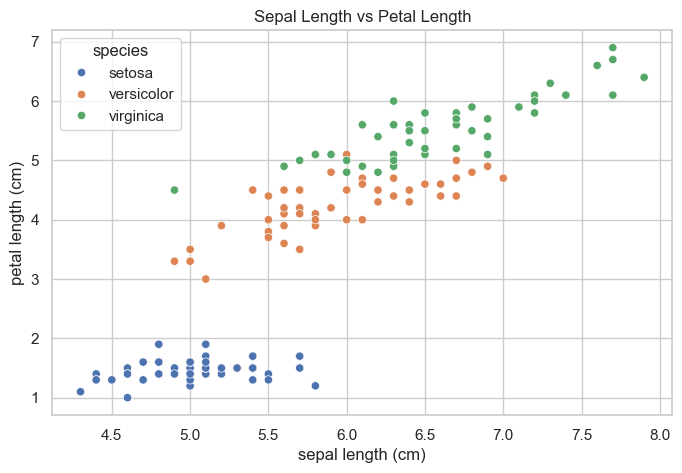

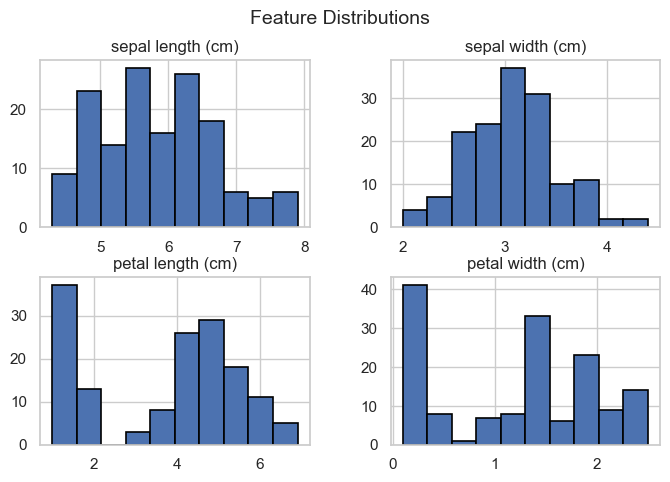

In [13]:

# =========================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# =========================

# -------------------------
# 4.1 Pairwise relationships
# -------------------------
sns.pairplot(df, hue="species")
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

# -------------------------
# 4.2 Scatter Plot
# -------------------------
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="petal length (cm)",
    hue="species"
)
plt.title("Sepal Length vs Petal Length")
plt.show()

# -------------------------
# 4.3 Histograms (Distribution)
# -------------------------
df.hist(edgecolor="black", linewidth=1.2)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()


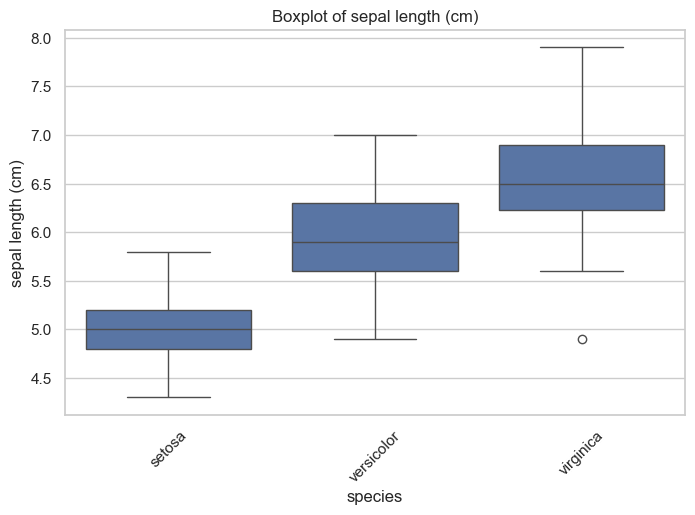

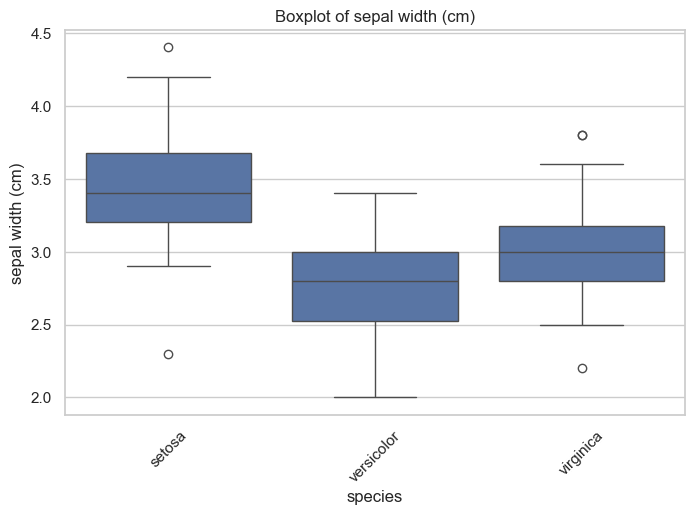

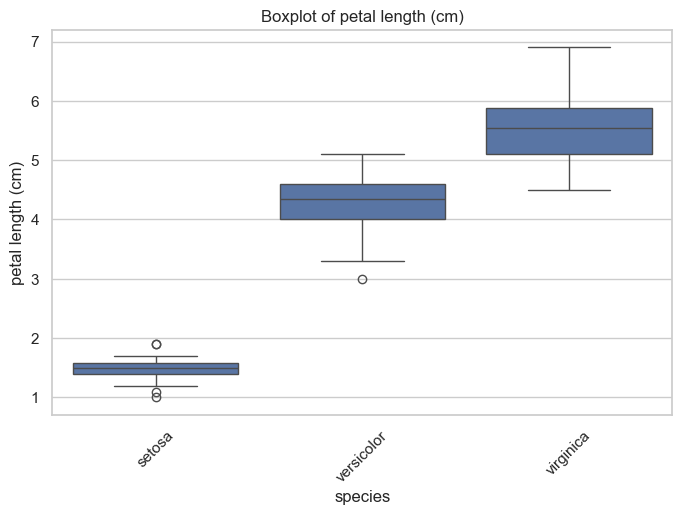

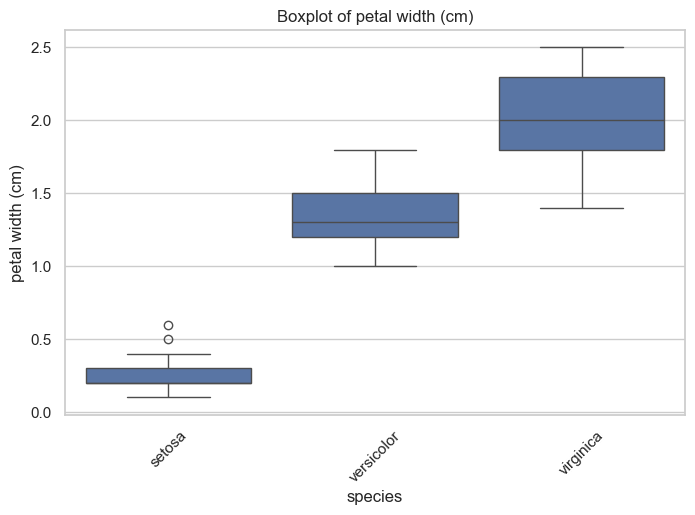

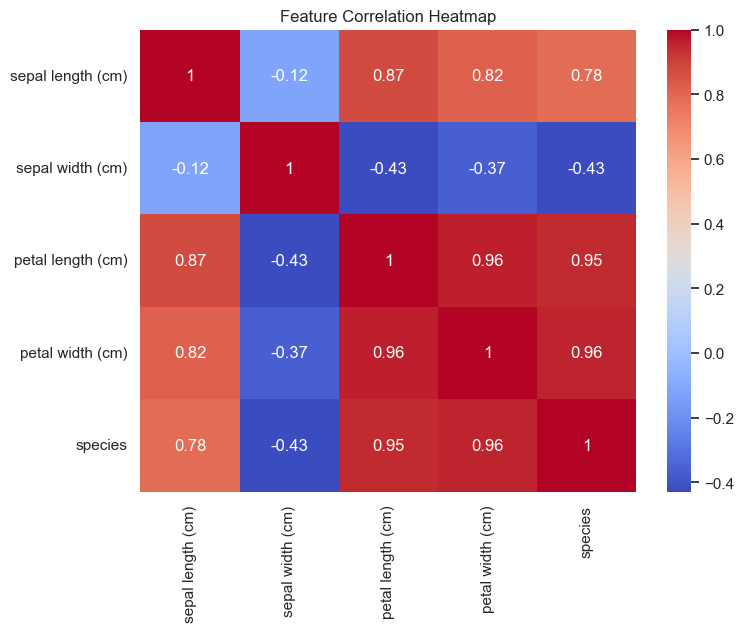

In [9]:

# -------------------------
# 4.4 Box Plots (Outlier Detection)
# -------------------------
for column in df.columns[:-1]:
    plt.figure()
    sns.boxplot(x="species", y=column, data=df)
    plt.title(f"Boxplot of {column}")
    plt.xticks(rotation=45)
    plt.show()

# =========================
# 5. CORRELATION ANALYSIS
# =========================

# Convert species to numeric for correlation
corr_df = df.copy()
corr_df["species"] = corr_df["species"].map({
    "setosa": 0,
    "versicolor": 1,
    "virginica": 2
})

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()